In [3]:
# packages
import pandas as pd
# import geopandas as gpd
import matplotlib.pyplot as plt
# from shapely.geometry import Point
import contextily as ctx

In [4]:
## Read in SOPP Dataset
BASE_PATH = "/Users/janavikolpekwar/CaseStudies/case_study"
sopp_df = pd.read_csv(f"{BASE_PATH}/tn_nashville_2020_04_01.csv")

/var/folders/n5/4t9x0f4j03n9b1tg992_l4lc0000gn/T/ipykernel_13950/1725907211.py:3: DtypeWarning: Columns (6,8,15,16,17,22,23,24,25,29,30,31,32,33,35,36,37,38,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  sopp_df = pd.read_csv(f"{BASE_PATH}/tn_nashville_2020_04_01.csv")


In [5]:
## Read in 2009 - 2019 Crash Dataset and Merge Each Year's Crash Dataset with Person Dataset
# 2009
acc9_df = pd.read_csv(f"{BASE_PATH}/ACCIDENT9.CSV")
acc9_tn_df = acc9_df[acc9_df['STATE'] == 47]
acc9_nash_df = acc9_tn_df[acc9_tn_df['CITY'] == 1760]

# 2010
acc10_df = pd.read_csv(f"{BASE_PATH}/ACCIDENT10.CSV")
acc10_tn_df = acc10_df[acc10_df['STATE'] == 47]
acc10_nash_df = acc10_tn_df[acc10_tn_df['CITY'] == 1760]

# 2011
acc11_df = pd.read_csv(f"{BASE_PATH}/ACCIDENT11.CSV")
acc11_tn_df = acc11_df[acc11_df['STATE'] == 47]
acc11_nash_df = acc11_tn_df[acc11_tn_df['CITY'] == 1760]

# 2012
acc12_df = pd.read_csv(f"{BASE_PATH}/ACCIDENT12.csv")
acc12_tn_df = acc12_df[acc12_df['STATE'] == 47]
acc12_nash_df = acc12_tn_df[acc12_tn_df['CITY'] == 1760]

# 2013
acc13_df = pd.read_csv(f"{BASE_PATH}/ACCIDENT13.csv")
acc13_tn_df = acc13_df[acc13_df['STATE'] == 47]
acc13_nash_df = acc13_tn_df[acc13_tn_df['CITY'] == 1760]

# 2014
acc14_df = pd.read_csv(f"{BASE_PATH}/ACCIDENT14.csv")
acc14_tn_df = acc14_df[acc14_df['STATE'] == 47]
acc14_nash_df = acc14_tn_df[acc14_tn_df['CITY'] == 1760]

# 2015
acc15_df = pd.read_csv(f"{BASE_PATH}/accident15.csv")
acc15_tn_df = acc15_df[acc15_df['STATE'] == 47]
acc15_nash_df = acc15_tn_df[acc15_tn_df['CITY'] == 1760]

# 2016
acc16_df = pd.read_csv(f"{BASE_PATH}/accident16.CSV")
acc16_tn_df = acc16_df[acc16_df['STATE'] == 47]
acc16_nash_df = acc16_tn_df[acc16_tn_df['CITY'] == 1760]

# 2017
acc17_df = pd.read_csv(f"{BASE_PATH}/accident17.CSV")
acc17_tn_df = acc17_df[acc17_df['STATE'] == 47]
acc17_nash_df = acc17_tn_df[acc17_tn_df['CITY'] == 1760]

# 2018
acc18_df = pd.read_csv(f"{BASE_PATH}/accident18.csv")
acc18_tn_df = acc18_df[acc18_df['STATE'] == 47]
acc18_nash_df = acc18_tn_df[acc18_tn_df['CITY'] == 1760]

# 2019
acc19_df = pd.read_csv(f"{BASE_PATH}/accident19.CSV", encoding = 'latin-1')
acc19_tn_df = acc19_df[acc19_df['STATE'] == 47]
acc19_nash_df = acc19_tn_df[acc19_tn_df['CITY'] == 1760]

/var/folders/n5/4t9x0f4j03n9b1tg992_l4lc0000gn/T/ipykernel_13950/3829525824.py:43: DtypeWarning: Columns (40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  acc17_df = pd.read_csv(f"{BASE_PATH}/accident17.CSV")
/var/folders/n5/4t9x0f4j03n9b1tg992_l4lc0000gn/T/ipykernel_13950/3829525824.py:53: DtypeWarning: Columns (40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  acc19_df = pd.read_csv(f"{BASE_PATH}/accident19.CSV", encoding = 'latin-1')


In [6]:
## Merge Crash Datasets
acc_nash_df = pd.concat([acc9_nash_df, acc10_nash_df, acc11_nash_df, acc12_nash_df,
                               acc13_nash_df, acc14_nash_df, acc15_nash_df, acc16_nash_df,
                               acc17_nash_df, acc18_nash_df, acc19_nash_df], ignore_index=True)

In [7]:
# Create lists of columns names for each year and find the ones that are present for all
list9 = acc9_nash_df.columns.tolist()
list10 = acc10_nash_df.columns.tolist()
list11 = acc11_nash_df.columns.tolist()
list12 = acc12_nash_df.columns.tolist()
list13 = acc13_nash_df.columns.tolist()
list14 = acc14_nash_df.columns.tolist()
list15 = acc15_nash_df.columns.tolist()
list16 = acc16_nash_df.columns.tolist()
list17 = acc17_nash_df.columns.tolist()
list18 = acc18_nash_df.columns.tolist()
list19 = acc19_nash_df.columns.tolist()

commons = set(list9).intersection(list10, list11, list12, list13, list14, list15, list16, list17, list18, list19)
columns = list(commons)

In [8]:
## Final Dataset
# remove any columns that aren't present for every year
df = acc_nash_df[columns]

In [9]:
# --- SOPP Data Prep ---
# Convert date and time strings into a datetime object
sopp_df['datetime'] = pd.to_datetime(sopp_df['date'] + ' ' + sopp_df['time'], errors='coerce')

# Extract hour and day of the week (0 = Monday, 6 = Sunday)
sopp_df['hour'] = sopp_df['datetime'].dt.hour
sopp_df['day_of_week'] = sopp_df['datetime'].dt.dayofweek 

# --- Crash Data Prep ---
# FARS dataset usually records unknown hours as 99, so we filter those out
df_clean_crashes = df[df['HOUR'] < 24].copy()

# FARS DAY_WEEK usually maps 1=Sunday, 2=Monday, ..., 7=Saturday
# We can map it to match the 0-6 (Mon-Sun) format of pandas for easy comparison
day_map = {2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 1: 6}
df_clean_crashes['mapped_day_of_week'] = df_clean_crashes['DAY_WEEK'].map(day_map)

Plot Hourly Histograms

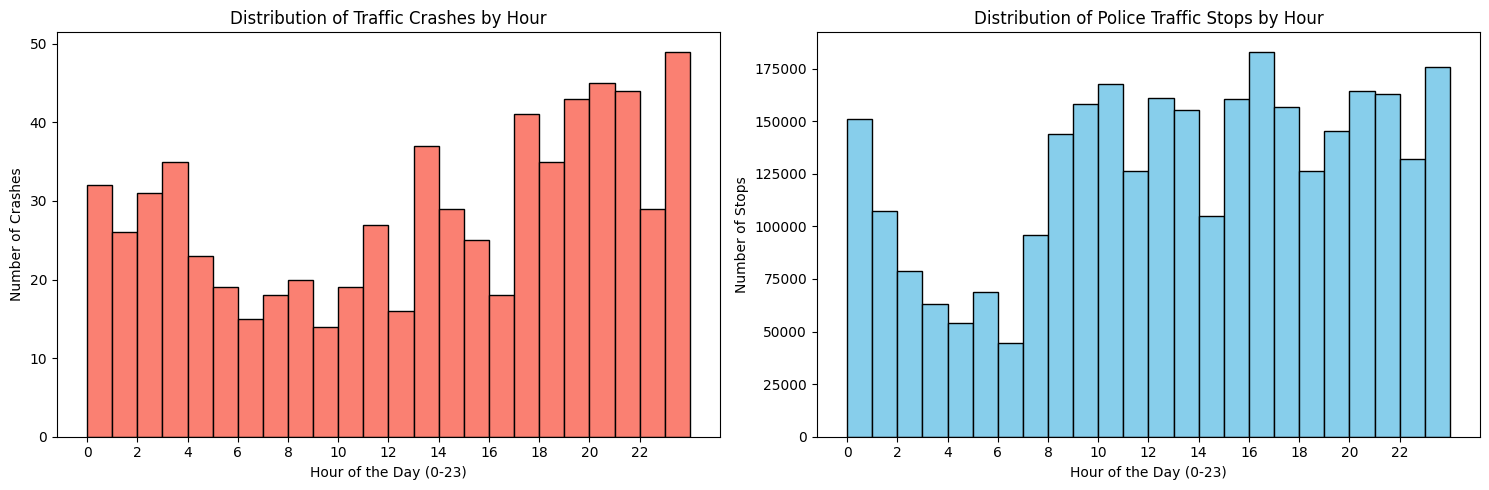

In [10]:
#  figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Crash Data by Hour Hist
axes[0].hist(df_clean_crashes['HOUR'].dropna(), bins=24, range=(0,24), color='salmon', edgecolor='black')
axes[0].set_title('Distribution of Traffic Crashes by Hour')
axes[0].set_xlabel('Hour of the Day (0-23)')
axes[0].set_ylabel('Number of Crashes')
axes[0].set_xticks(range(0, 24, 2))

# Police Stops by Hour Hist
axes[1].hist(sopp_df['hour'].dropna(), bins=24, range=(0,24), color='skyblue', edgecolor='black')
axes[1].set_title('Distribution of Police Traffic Stops by Hour')
axes[1].set_xlabel('Hour of the Day (0-23)')
axes[1].set_ylabel('Number of Stops')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

Day of the Week Histogram 

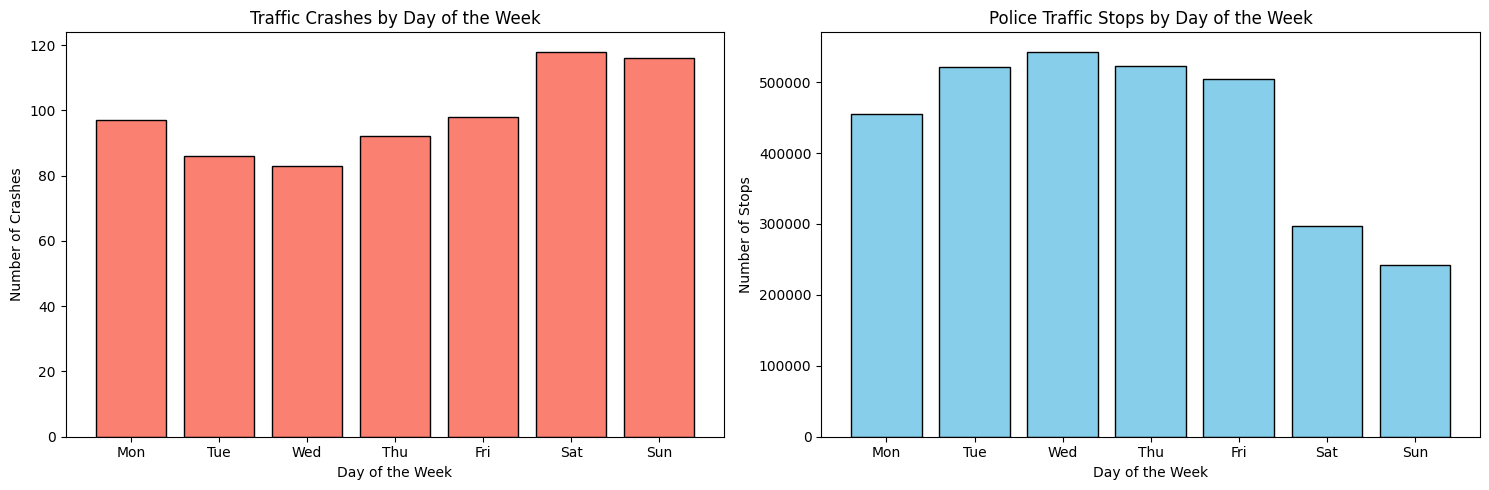

In [11]:
days_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Crash Data by Day of Week Hist
axes[0].hist(df_clean_crashes['mapped_day_of_week'].dropna(), bins=7, range=(-0.5, 6.5), color='salmon', edgecolor='black', rwidth=0.8)
axes[0].set_title('Traffic Crashes by Day of the Week')
axes[0].set_xlabel('Day of the Week')
axes[0].set_ylabel('Number of Crashes')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(days_labels)

# Police Stops by Day of Week Hist
axes[1].hist(sopp_df['day_of_week'].dropna(), bins=7, range=(-0.5, 6.5), color='skyblue', edgecolor='black', rwidth=0.8)
axes[1].set_title('Police Traffic Stops by Day of the Week')
axes[1].set_xlabel('Day of the Week')
axes[1].set_ylabel('Number of Stops')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days_labels)

plt.tight_layout()
plt.show()

Poisson Linear Regression Model

In [12]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

#  count of crashes (Y) for each temporal window (X)
crashes_grouped = df_clean_crashes.groupby(['MONTH', 'mapped_day_of_week', 'HOUR']).size().reset_index(name='crash_count')
crashes_grouped.head()

,MONTH,mapped_day_of_week,HOUR,crash_count
0,1,0,0,1
1,1,0,9,1
2,1,0,15,1
3,1,0,17,2
4,1,0,18,1


In [13]:
# Set up the Poisson regression formula
# Y = crash_count, X = HOUR (treated as categorical)
formula = "crash_count ~ C(HOUR) + C(mapped_day_of_week)" 
poisson_model = smf.poisson(formula, data=crashes_grouped).fit()
print(poisson_model.summary())

Optimization terminated successfully.
         Current function value: 1.139609
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:            crash_count   No. Observations:                  567
Model:                        Poisson   Df Residuals:                      537
Method:                           MLE   Df Model:                           29
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                0.004353
Time:                        21:28:14   Log-Likelihood:                -646.16
converged:                       True   LL-Null:                       -648.98
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.1219      0.203      0.599      0.549      

In [14]:
# Expanded model incorporating all temporal variables
expanded_formula = "crash_count ~ C(HOUR) + C(mapped_day_of_week) + C(MONTH)"
expanded_poisson_model = smf.poisson(expanded_formula, data=crashes_grouped).fit()
print(expanded_poisson_model.summary())

Optimization terminated successfully.
         Current function value: 1.138718
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:            crash_count   No. Observations:                  567
Model:                        Poisson   Df Residuals:                      526
Method:                           MLE   Df Model:                           40
Date:                Fri, 06 Mar 2026   Pseudo R-squ.:                0.005132
Time:                        21:28:14   Log-Likelihood:                -645.65
converged:                       True   LL-Null:                       -648.98
Covariance Type:            nonrobust   LLR p-value:                     1.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      0.0962      0.239      0.402      0.687      

In [15]:
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf

# 80/20 split on your grouped crash data
# test_size=0.20 means 20% for testing, 80% for training
# random_state=42 ensures you get the exact same split every time you run the cell
train_data, test_data = train_test_split(crashes_grouped, test_size=0.20, random_state=42)

# Verify the sizes of the split
print(f"Total observations: {len(crashes_grouped)}")
print(f"Training observations (80%): {len(train_data)}")
print(f"Testing observations (20%): {len(test_data)}\n")

# 2. Fit the Poisson model ONLY on the Training Data
formula = "crash_count ~ C(HOUR)"
poisson_train_model = smf.poisson(formula, data=train_data).fit()

test_predictions = test_data.copy()
test_predictions['predicted_crashes'] = poisson_train_model.predict(test_predictions)

# 4. actual vs predicted results for the test set
print("Test Set Predictions:")
print(test_predictions[['HOUR', 'mapped_day_of_week', 'MONTH', 'crash_count', 'predicted_crashes']].head())

Total observations: 567
Training observations (80%): 453
Testing observations (20%): 114

Optimization terminated successfully.
         Current function value: 1.150925
         Iterations 5
Test Set Predictions:
     HOUR  mapped_day_of_week  MONTH  crash_count  predicted_crashes
540    18                   3     12            1           1.300000
525    17                   0     12            1           1.307692
234    22                   2      6            1           1.166667
526     3                   1     12            1           1.333333
490     2                   3     11            1           1.200000


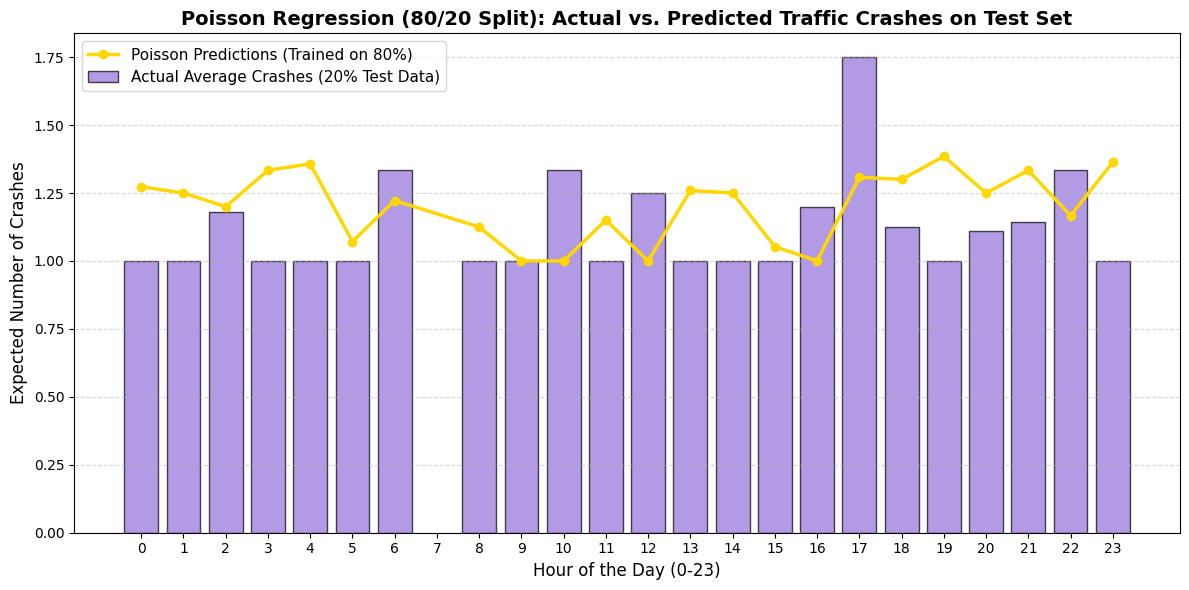

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

test_actual_hourly_crashes = test_data.groupby('HOUR')['crash_count'].mean().reset_index()
test_predicted_hourly_crashes = test_predictions.groupby('HOUR')['predicted_crashes'].mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(test_actual_hourly_crashes['HOUR'], test_actual_hourly_crashes['crash_count'], 
       color='mediumpurple', edgecolor='black', alpha=0.7, label='Actual Average Crashes (20% Test Data)')
ax.plot(test_predicted_hourly_crashes['HOUR'], test_predicted_hourly_crashes['predicted_crashes'], 
        color='gold', marker='o', linestyle='-', linewidth=2.5, markersize=6, 
        label='Poisson Predictions (Trained on 80%)')

ax.set_title('Poisson Regression (80/20 Split): Actual vs. Predicted Traffic Crashes on Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of the Day (0-23)', fontsize=12)
ax.set_ylabel('Expected Number of Crashes', fontsize=12)
ax.set_xticks(np.arange(0, 24, 1))
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Linear model vs. GLM

Lin Reg (partial correlation)
Y(not continuous(i.e. categorical or numerical))

Zero Inflated Poisson LRM
Simple LM

Nuanced LM (controlling other predictors)

(Causal Question)
1. Use aggregate by hour (87000 observations)
2. Poisson Model hour of the day, day of the week, and month


Slope of X (E(Y) link func (conditional mu of Y))
Link Func (Poisson)
Log Func (Log odds ratio ~ exp)

Generalized additive model for Poisson regression: crash counts per hour ~ hour of the day (nonlinear effect), day of the week, month, year (categorical for day, month, year)

Zero Inflated Model (If we have a bunch of zeros, Poisson LM may not be a good candidate)

Spatial EDA
1. Heatmaps (stop & crash) - already done

Temporal EDA
Crash df
Hour (Non-linear effect to visualize temporal change)
Day of Week (Categorical) - 1 day as baseline rest dummy vars
Month (Categorical) - 1 month as baseline rest dummy vars
Year (Categorical) - 1 year as a baseline rest dummy vars

Stop df 
filter out speeding for stop and compare to crashes
Hour (Non-linear effect to visualize temporal change)
Day of Week (Categorical) - 1 day as baseline rest dummy vars
Month (Categorical) - 1 month as baseline rest dummy vars
Year (Categorical) - 1 year as a baseline rest dummy vars

Step 1: Aggregate crash count by hour




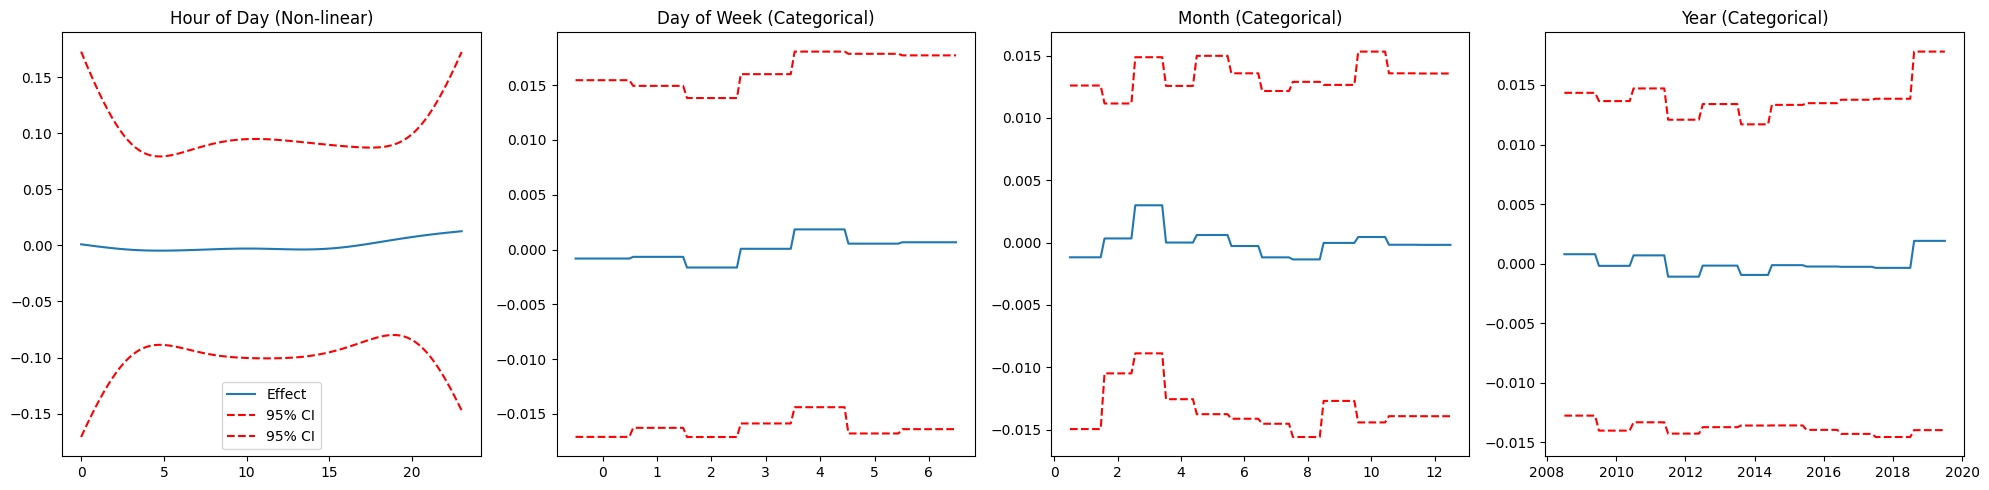

In [19]:
import numpy as np
from pygam import PoissonGAM, s, f

# ---------------------------------------------------------
# Step 4: Visualize the Partial Dependence Plots (Fixed)
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
titles = ['Hour of Day (Non-linear)', 'Day of Week (Categorical)', 
          'Month (Categorical)', 'Year (Categorical)']

# Calculate a valid baseline (median) for all features from your training data
# This prevents pygam from trying to evaluate at Month 0 or Year 0
baseline_values = np.median(X, axis=0)

for i, ax in enumerate(axs):
    # Generate an X grid for the specific feature to predict partial dependence
    XX = gam.generate_X_grid(term=i)
    
    # ------------------ THE FIX ------------------
    # Replace pygam's default 0.0s with our valid baseline values 
    for j in range(X.shape[1]):
        if i != j:  # If it's not the feature we are currently plotting
            XX[:, j] = baseline_values[j]
    # ---------------------------------------------
    
    # Plot the partial dependence line and the 95% confidence intervals
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX), label='Effect')
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], 
            c='r', ls='--', label='95% CI')
    
    ax.set_title(titles[i])
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()